<a href="https://colab.research.google.com/github/annavarapunavya/annavarapunavya/blob/main/Bike_sharing_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
dataset=pd.read_csv('BikeSharing.csv')

In [ ]:
dataset

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,726,27-12-2019,1,1,12,0,4,1,2,10.420847,11.33210,65.2917,23.458911,247,1867,2114
726,727,28-12-2019,1,1,12,0,5,1,2,10.386653,12.75230,59.0000,10.416557,644,2451,3095
727,728,29-12-2019,1,1,12,0,6,0,2,10.386653,12.12000,75.2917,8.333661,159,1182,1341
728,729,30-12-2019,1,1,12,0,0,0,1,10.489153,11.58500,48.3333,23.500518,364,1432,1796


In [ ]:
dataset.shape

(730, 16)

In [ ]:
dataset.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [ ]:
dataset.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.997260,0.683562,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.006161,0.465405,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


In [ ]:
#Assigning string values to different seasons instead of numeric values

# 1= spring
dataset.loc[dataset['season']==1,'season']='spring'

#2=summer
dataset.loc[dataset['season']==2,'season']='summer'

#3=fall
dataset.loc[dataset['season']==3,'season']='fall'

#4=winter
dataset.loc[dataset['season']==4,'season']='winter'

In [ ]:
dataset['season'].astype('category').value_counts()

,count
season,
fall,188
summer,184
spring,180
winter,178


In [ ]:
# 0=2018, 1=2019 : year
dataset['yr'].astype('category').value_counts()

,count
yr,
0,365
1,365


In [ ]:
def object_map_mnths(x):
  return x.map({1: 'Jan', 2: 'Feb', 3:'Mar', 4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sept', 10:'oct', 11:'Nov', 12:'Dec'})

In [ ]:
dataset[['mnth']] = dataset[['mnth']].apply(object_map_mnths)

In [ ]:
dataset['mnth'].astype('category').value_counts()

,count
mnth,
Aug,62
Dec,62
Jul,62
Jan,62
oct,62
May,62
Mar,62
Apr,60
Nov,60


In [ ]:
dataset['holiday'].astype('category').value_counts()

,count
holiday,
0,709
1,21


In [ ]:
def str_map_weekday(x):
  return x.map({1:'Mon', 2:'Tues', 3:'wed', 4:'Thrus', 5:'Fri', 6:'Sat', 0:'Sun'})

In [ ]:
dataset[['weekday']]=dataset[['weekday']].apply(str_map_weekday)

In [ ]:
dataset['weekday'].astype('category').value_counts()

,count
weekday,
Mon,105
Sat,105
Sun,105
Fri,104
Thrus,104
Tues,104
wed,103


In [ ]:
dataset['workingday'].astype('category').value_counts()

,count
workingday,
1,499
0,231


In [ ]:
# 1 = clear, few clouds, partily cloudly
dataset.loc[(dataset['weathersit'] == 1), 'weathersit'] = 'A'

# 2 = Mist, cloudly
dataset.loc[(dataset['weathersit'] == 2), 'weathersit'] = 'B'

# 3 = Heavy rain, light snow
dataset.loc[(dataset['weathersit'] == 3), 'weathersit'] = 'C'


In [ ]:
dataset['weathersit'].astype('category').value_counts()

,count
weathersit,
A,463
B,246
C,21


**DATA VISUALISATION**

In [ ]:
# Importing libs
import matplotlib.pyplot as plt
import seaborn as sns

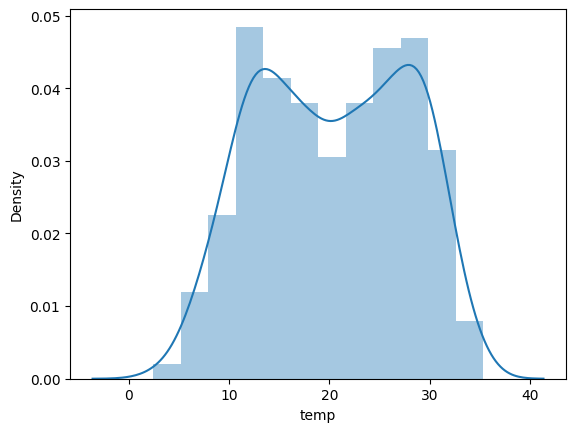

In [ ]:
# Temperature
sns.distplot(dataset['temp'])
plt.show()

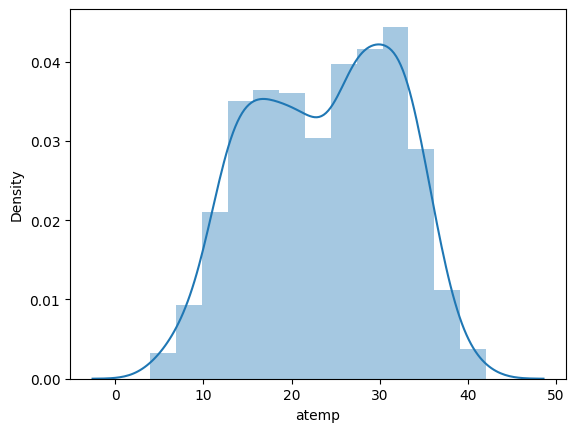

In [ ]:
# Actual Temperature
sns.distplot(dataset['atemp'])
plt.show()

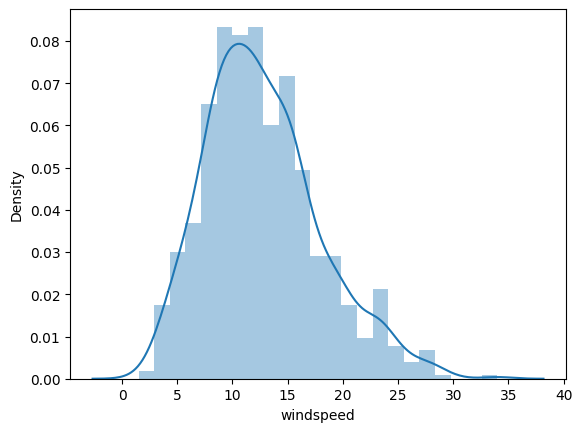

In [ ]:
# wind speed

sns.distplot(dataset['windspeed'])
plt.show()

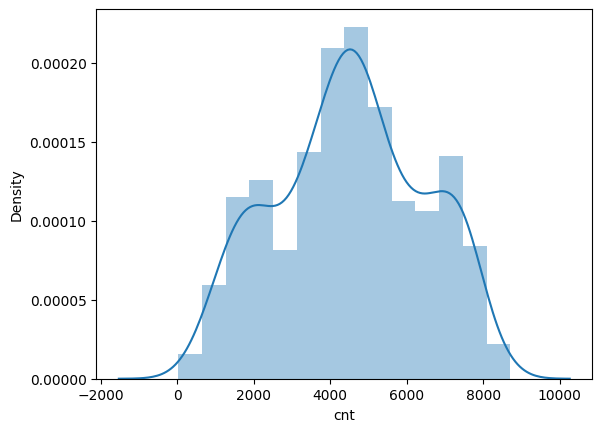

In [ ]:
# Target variable: count of total rental bikes including both casual and registered

sns.distplot(dataset['cnt'])
plt.show()

In [ ]:
dataset['dteday'] = dataset['dteday'].astype('datetime64[ns]')

In [ ]:
dataset_categorical = dataset.select_dtypes(exclude=['float64', 'datetime64', 'int64'])


In [ ]:
dataset_categorical.columns

Index(['season', 'mnth', 'weekday', 'weathersit'], dtype='object')

In [ ]:
dataset_categorical

,season,mnth,weekday,weathersit
0,spring,Jan,Sat,B
1,spring,Jan,Sun,B
2,spring,Jan,Mon,A
3,spring,Jan,Tues,A
4,spring,Jan,wed,A
...,...,...,...,...
725,spring,Dec,Thrus,B
726,spring,Dec,Fri,B
727,spring,Dec,Sat,B
728,spring,Dec,Sun,A


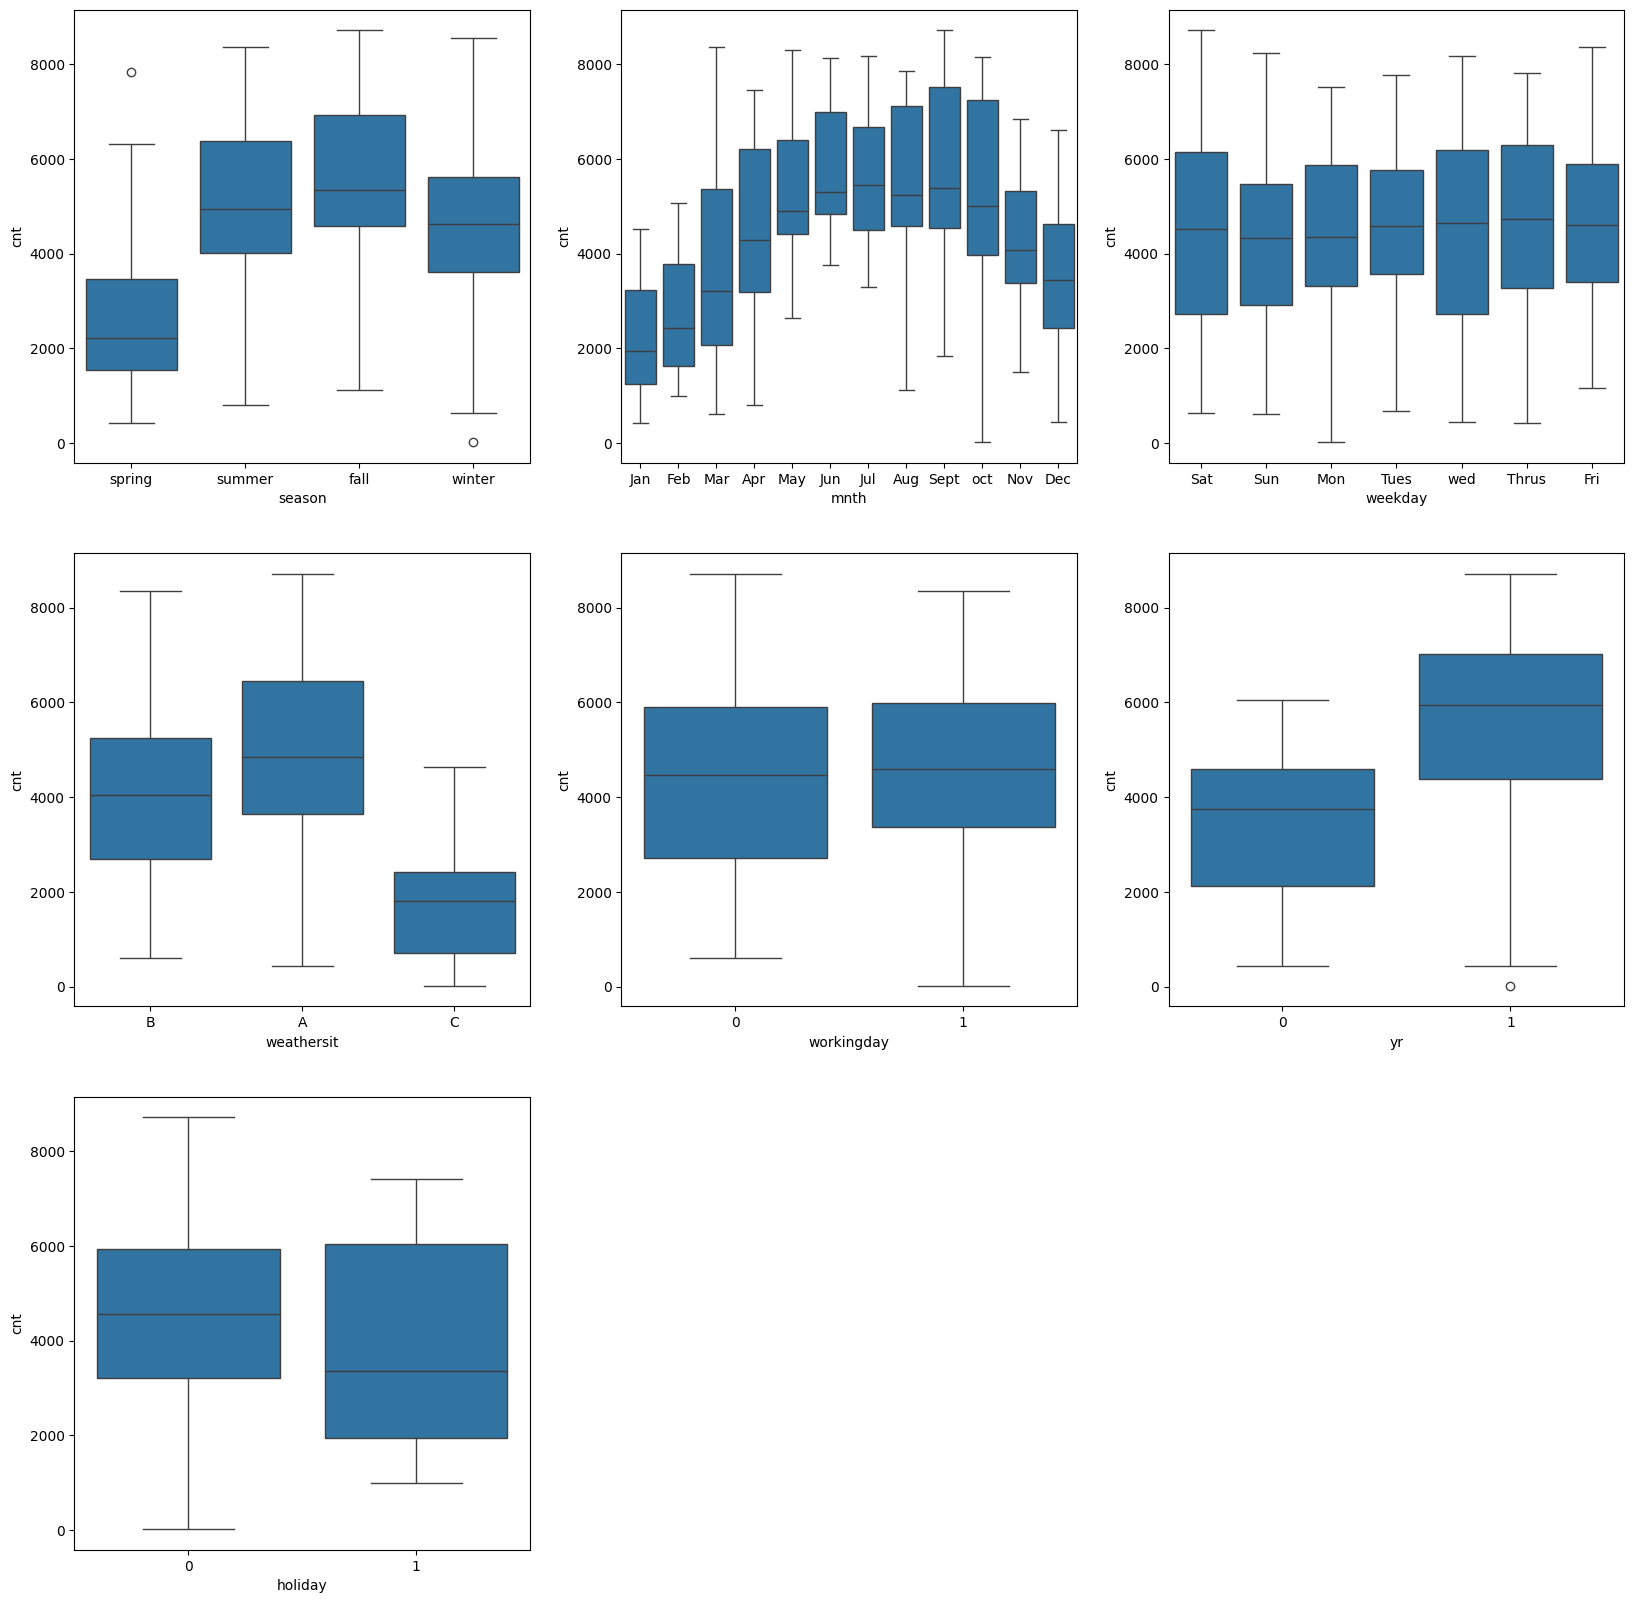

In [ ]:
plt.figure(figsize=(20,20))
plt.subplot(3,3,1)
sns.boxplot(x = 'season', y = 'cnt', data = dataset)
plt.subplot(3,3,2)
sns.boxplot(x = 'mnth', y = 'cnt', data = dataset)
plt.subplot(3,3,3)
sns.boxplot(x = 'weekday', y = 'cnt', data = dataset)
plt.subplot(3,3,4)
sns.boxplot(x = 'weathersit', y = 'cnt', data = dataset)
plt.subplot(3,3,5)
sns.boxplot(x = 'workingday', y = 'cnt', data = dataset)
plt.subplot(3,3,6)
sns.boxplot(x = 'yr', y = 'cnt', data = dataset)
plt.subplot(3,3,7)
sns.boxplot(x = 'holiday', y = 'cnt', data = dataset)
plt.show()

In [ ]:
intVarlist = ["casual", "registered", "cnt"]

for var in intVarlist:
  dataset[var] = dataset[var].astype("float")

In [ ]:
dataset_numeric = dataset.select_dtypes(include=['float64'])
dataset_numeric.head()

,temp,atemp,hum,windspeed,casual,registered,cnt
0,14.110847,18.18125,80.5833,10.749882,331.0,654.0,985.0
1,14.902598,17.68695,69.6087,16.652113,131.0,670.0,801.0
2,8.050924,9.47025,43.7273,16.636703,120.0,1229.0,1349.0
3,8.200000,10.60610,59.0435,10.739832,108.0,1454.0,1562.0
4,9.305237,11.46350,43.6957,12.522300,82.0,1518.0,1600.0


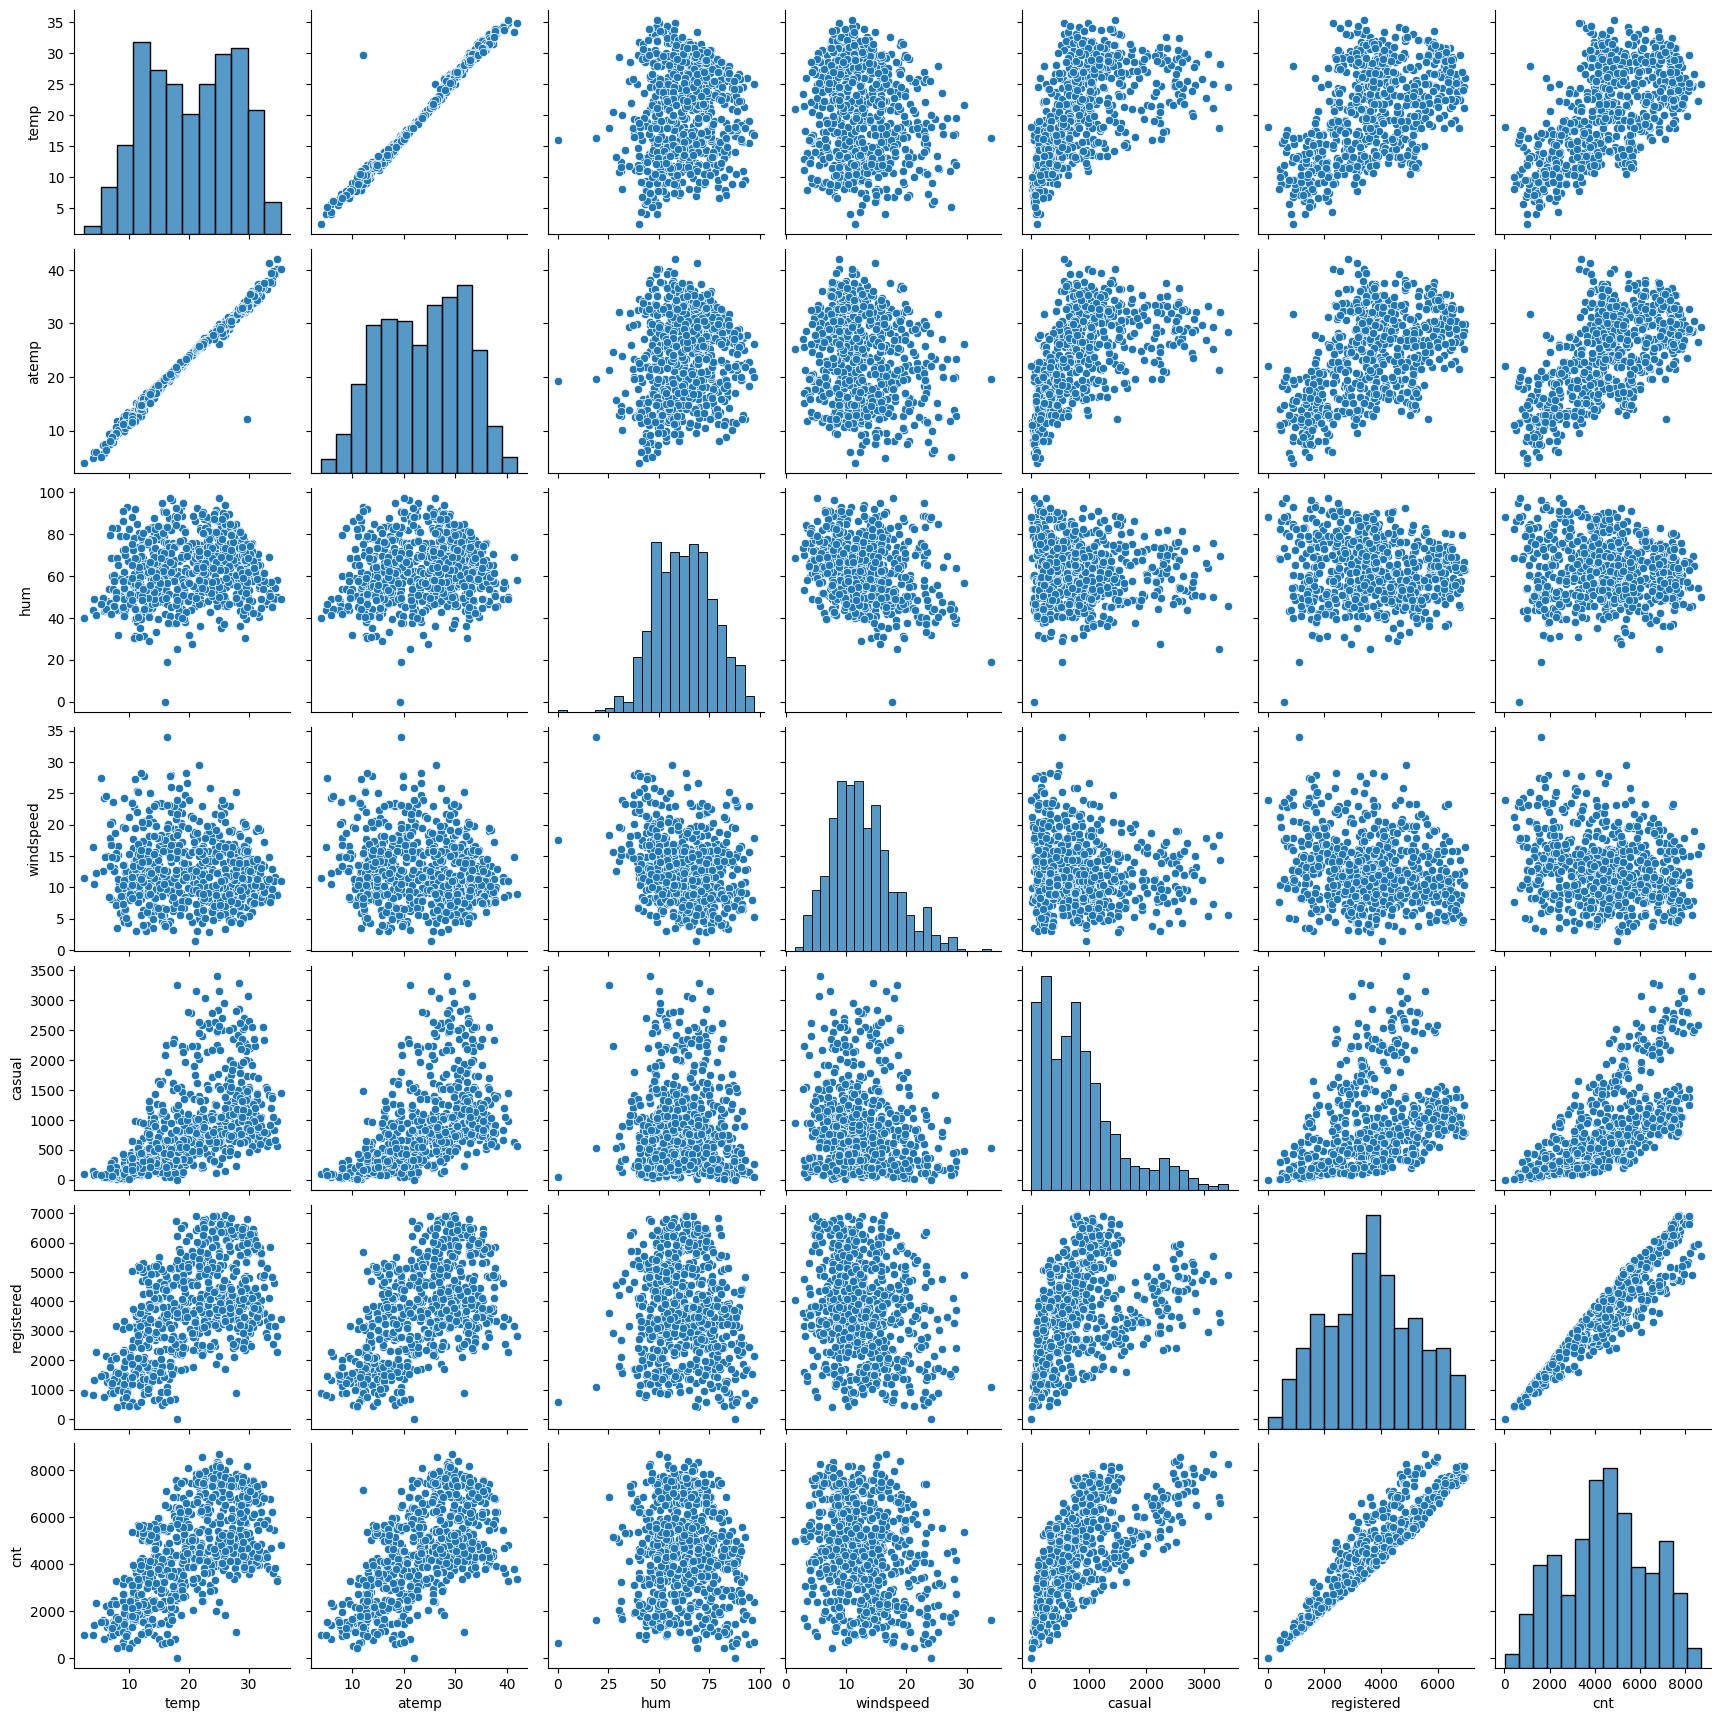

In [ ]:
sns.pairplot(dataset_numeric)
plt.show()

In [ ]:
cor = dataset_numeric.corr()
cor

In [ ]:
# heatmap
mask = np.array(cor)
mask[np.tril_indices_from(mask)]=False
fig,ax=plt.subplots()
fig.set_size_inches(20,10)
sns.heatmap(cor,mask=mask,vmax=0.9,square=True,annot=True)

NameError: name 'cor' is not defined

In [ ]:
# Removing atemp as it is highly corealed with temp
dataset.drop('atemp', axis=1, inplace=True)

In [ ]:
dataset

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,casual,registered,cnt
0,1,2018-01-01,spring,0,Jan,0,Sat,0,B,14.110847,80.5833,10.749882,331.0,654.0,985.0
1,2,2018-02-01,spring,0,Jan,0,Sun,0,B,14.902598,69.6087,16.652113,131.0,670.0,801.0
2,3,2018-03-01,spring,0,Jan,0,Mon,1,A,8.050924,43.7273,16.636703,120.0,1229.0,1349.0
3,4,2018-04-01,spring,0,Jan,0,Tues,1,A,8.200000,59.0435,10.739832,108.0,1454.0,1562.0
4,5,2018-05-01,spring,0,Jan,0,wed,1,A,9.305237,43.6957,12.522300,82.0,1518.0,1600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,726,2019-12-27,spring,1,Dec,0,Thrus,1,B,10.420847,65.2917,23.458911,247.0,1867.0,2114.0
726,727,2019-12-28,spring,1,Dec,0,Fri,1,B,10.386653,59.0000,10.416557,644.0,2451.0,3095.0
727,728,2019-12-29,spring,1,Dec,0,Sat,0,B,10.386653,75.2917,8.333661,159.0,1182.0,1341.0
728,729,2019-12-30,spring,1,Dec,0,Sun,0,A,10.489153,48.3333,23.500518,364.0,1432.0,1796.0


**DATA PREPARATION**

In [ ]:
dataset_categorial = dataset.select_dtypes(include=['object'])
dataset_categorial.head()

,season,mnth,weekday,weathersit
0,spring,Jan,Sat,B
1,spring,Jan,Sun,B
2,spring,Jan,Mon,A
3,spring,Jan,Tues,A
4,spring,Jan,wed,A


In [ ]:
dataset_dummies = pd.get_dummies(dataset_categorial, drop_first=True)
dataset_dummies.head()

,season_spring,season_summer,season_winter,mnth_Aug,mnth_Dec,mnth_Feb,mnth_Jan,mnth_Jul,mnth_Jun,mnth_Mar,...,mnth_Sept,mnth_oct,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thrus,weekday_Tues,weekday_wed,weathersit_B,weathersit_C
0,True,False,False,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,True,False
1,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2,True,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
dataset_dummies = pd.get_dummies(dataset_categorial, drop_first=True)
dataset_dummies.head()

,season_spring,season_summer,season_winter,mnth_Aug,mnth_Dec,mnth_Feb,mnth_Jan,mnth_Jul,mnth_Jun,mnth_Mar,...,mnth_Sept,mnth_oct,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thrus,weekday_Tues,weekday_wed,weathersit_B,weathersit_C
0,True,False,False,False,False,False,True,False,False,False,...,False,False,False,True,False,False,False,False,True,False
1,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2,True,False,False,False,False,False,True,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,True,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
dataset = dataset.drop(list(dataset_categorial.columns), axis=1)
dataset

,instant,dteday,yr,holiday,workingday,temp,hum,windspeed,casual,registered,cnt
0,1,2018-01-01,0,0,0,14.110847,80.5833,10.749882,331.0,654.0,985.0
1,2,2018-02-01,0,0,0,14.902598,69.6087,16.652113,131.0,670.0,801.0
2,3,2018-03-01,0,0,1,8.050924,43.7273,16.636703,120.0,1229.0,1349.0
3,4,2018-04-01,0,0,1,8.200000,59.0435,10.739832,108.0,1454.0,1562.0
4,5,2018-05-01,0,0,1,9.305237,43.6957,12.522300,82.0,1518.0,1600.0
...,...,...,...,...,...,...,...,...,...,...,...
725,726,2019-12-27,1,0,1,10.420847,65.2917,23.458911,247.0,1867.0,2114.0
726,727,2019-12-28,1,0,1,10.386653,59.0000,10.416557,644.0,2451.0,3095.0
727,728,2019-12-29,1,0,0,10.386653,75.2917,8.333661,159.0,1182.0,1341.0
728,729,2019-12-30,1,0,0,10.489153,48.3333,23.500518,364.0,1432.0,1796.0


In [ ]:
dataset=pd.concat([dataset, dataset_dummies], axis=1)

In [ ]:
dataset

,instant,dteday,yr,holiday,workingday,temp,hum,windspeed,casual,registered,...,mnth_Sept,mnth_oct,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thrus,weekday_Tues,weekday_wed,weathersit_B,weathersit_C
0,1,2018-01-01,0,0,0,14.110847,80.5833,10.749882,331.0,654.0,...,False,False,False,True,False,False,False,False,True,False
1,2,2018-02-01,0,0,0,14.902598,69.6087,16.652113,131.0,670.0,...,False,False,False,False,True,False,False,False,True,False
2,3,2018-03-01,0,0,1,8.050924,43.7273,16.636703,120.0,1229.0,...,False,False,True,False,False,False,False,False,False,False
3,4,2018-04-01,0,0,1,8.200000,59.0435,10.739832,108.0,1454.0,...,False,False,False,False,False,False,True,False,False,False
4,5,2018-05-01,0,0,1,9.305237,43.6957,12.522300,82.0,1518.0,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,726,2019-12-27,1,0,1,10.420847,65.2917,23.458911,247.0,1867.0,...,False,False,False,False,False,True,False,False,True,False
726,727,2019-12-28,1,0,1,10.386653,59.0000,10.416557,644.0,2451.0,...,False,False,False,False,False,False,False,False,True,False
727,728,2019-12-29,1,0,0,10.386653,75.2917,8.333661,159.0,1182.0,...,False,False,False,True,False,False,False,False,True,False
728,729,2019-12-30,1,0,0,10.489153,48.3333,23.500518,364.0,1432.0,...,False,False,False,False,True,False,False,False,False,False


In [ ]:
dataset = dataset.drop(['casual', 'registered'], axis=1, inplace=False)
dataset.head()

,instant,dteday,yr,holiday,workingday,temp,hum,windspeed,cnt,season_spring,...,mnth_Sept,mnth_oct,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thrus,weekday_Tues,weekday_wed,weathersit_B,weathersit_C
0,1,2018-01-01,0,0,0,14.110847,80.5833,10.749882,985.0,True,...,False,False,False,True,False,False,False,False,True,False
1,2,2018-02-01,0,0,0,14.902598,69.6087,16.652113,801.0,True,...,False,False,False,False,True,False,False,False,True,False
2,3,2018-03-01,0,0,1,8.050924,43.7273,16.636703,1349.0,True,...,False,False,True,False,False,False,False,False,False,False
3,4,2018-04-01,0,0,1,8.200000,59.0435,10.739832,1562.0,True,...,False,False,False,False,False,False,True,False,False,False
4,5,2018-05-01,0,0,1,9.305237,43.6957,12.522300,1600.0,True,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
# Import Libs
from sklearn import linear_model
from sklearn.linear_model import LinearRegression

In [ ]:
#Split the dataframe into train and test dataset
from sklearn.model_selection import train_test_split
np.random.seed(0)
df_train, df_test = train_test_split(dataset, train_size=0.7, test_size=0.3, random_state=100)

In [ ]:
df_train

,instant,dteday,yr,holiday,workingday,temp,hum,windspeed,cnt,season_spring,...,mnth_Sept,mnth_oct,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thrus,weekday_Tues,weekday_wed,weathersit_B,weathersit_C
653,654,2019-10-16,1,0,1,19.201653,55.8333,12.208807,7534.0,False,...,False,True,False,False,False,False,True,False,False,False
576,577,2019-07-31,1,0,1,29.246653,70.4167,11.083475,7216.0,False,...,False,False,False,False,False,False,True,False,False,False
426,427,2019-03-03,1,0,0,16.980847,62.1250,10.792293,4066.0,True,...,False,False,False,True,False,False,False,False,True,False
728,729,2019-12-30,1,0,0,10.489153,48.3333,23.500518,1796.0,True,...,False,False,False,False,True,False,False,False,False,False
482,483,2019-04-28,1,0,0,15.443347,48.9583,8.708325,4220.0,False,...,False,False,False,True,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
526,527,2019-11-06,1,0,1,29.554153,58.7917,13.916771,6664.0,False,...,False,False,True,False,False,False,False,False,True,False
578,579,2019-02-08,1,0,1,30.852500,65.9583,8.666718,7261.0,False,...,False,False,False,False,False,True,False,False,False,False
53,54,2018-02-23,0,0,1,9.091299,42.3043,6.305571,1917.0,True,...,False,False,False,False,False,False,False,True,False,False
350,351,2018-12-17,0,0,0,10.591653,56.0833,16.292189,2739.0,False,...,False,False,False,True,False,False,False,False,True,False


In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [ ]:
#Applying scaler to all columns expect dummy variables
var =["temp", "hum", "windspeed", "cnt"]
df_train[var] = scaler.fit_transform(df_train[var])

In [ ]:
df_train.describe()

,instant,dteday,yr,holiday,workingday,temp,hum,windspeed,cnt
count,510.000000,510,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000
mean,368.941176,2019-01-02 21:04:56.470588160,0.507843,0.025490,0.676471,0.537262,0.650369,0.320768,0.513620
min,1.000000,2018-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,187.250000,2018-07-01 06:00:00,0.000000,0.000000,0.000000,0.339853,0.538643,0.199179,0.356420
50%,373.000000,2019-01-05 12:00:00,1.000000,0.000000,1.000000,0.540519,0.653714,0.296763,0.518638
75%,553.750000,2019-07-07 18:00:00,1.000000,0.000000,1.000000,0.735215,0.754830,0.414447,0.684710
max,729.000000,2019-12-30 00:00:00,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
std,209.868619,NaN,0.500429,0.157763,0.468282,0.225844,0.145882,0.169797,0.224593


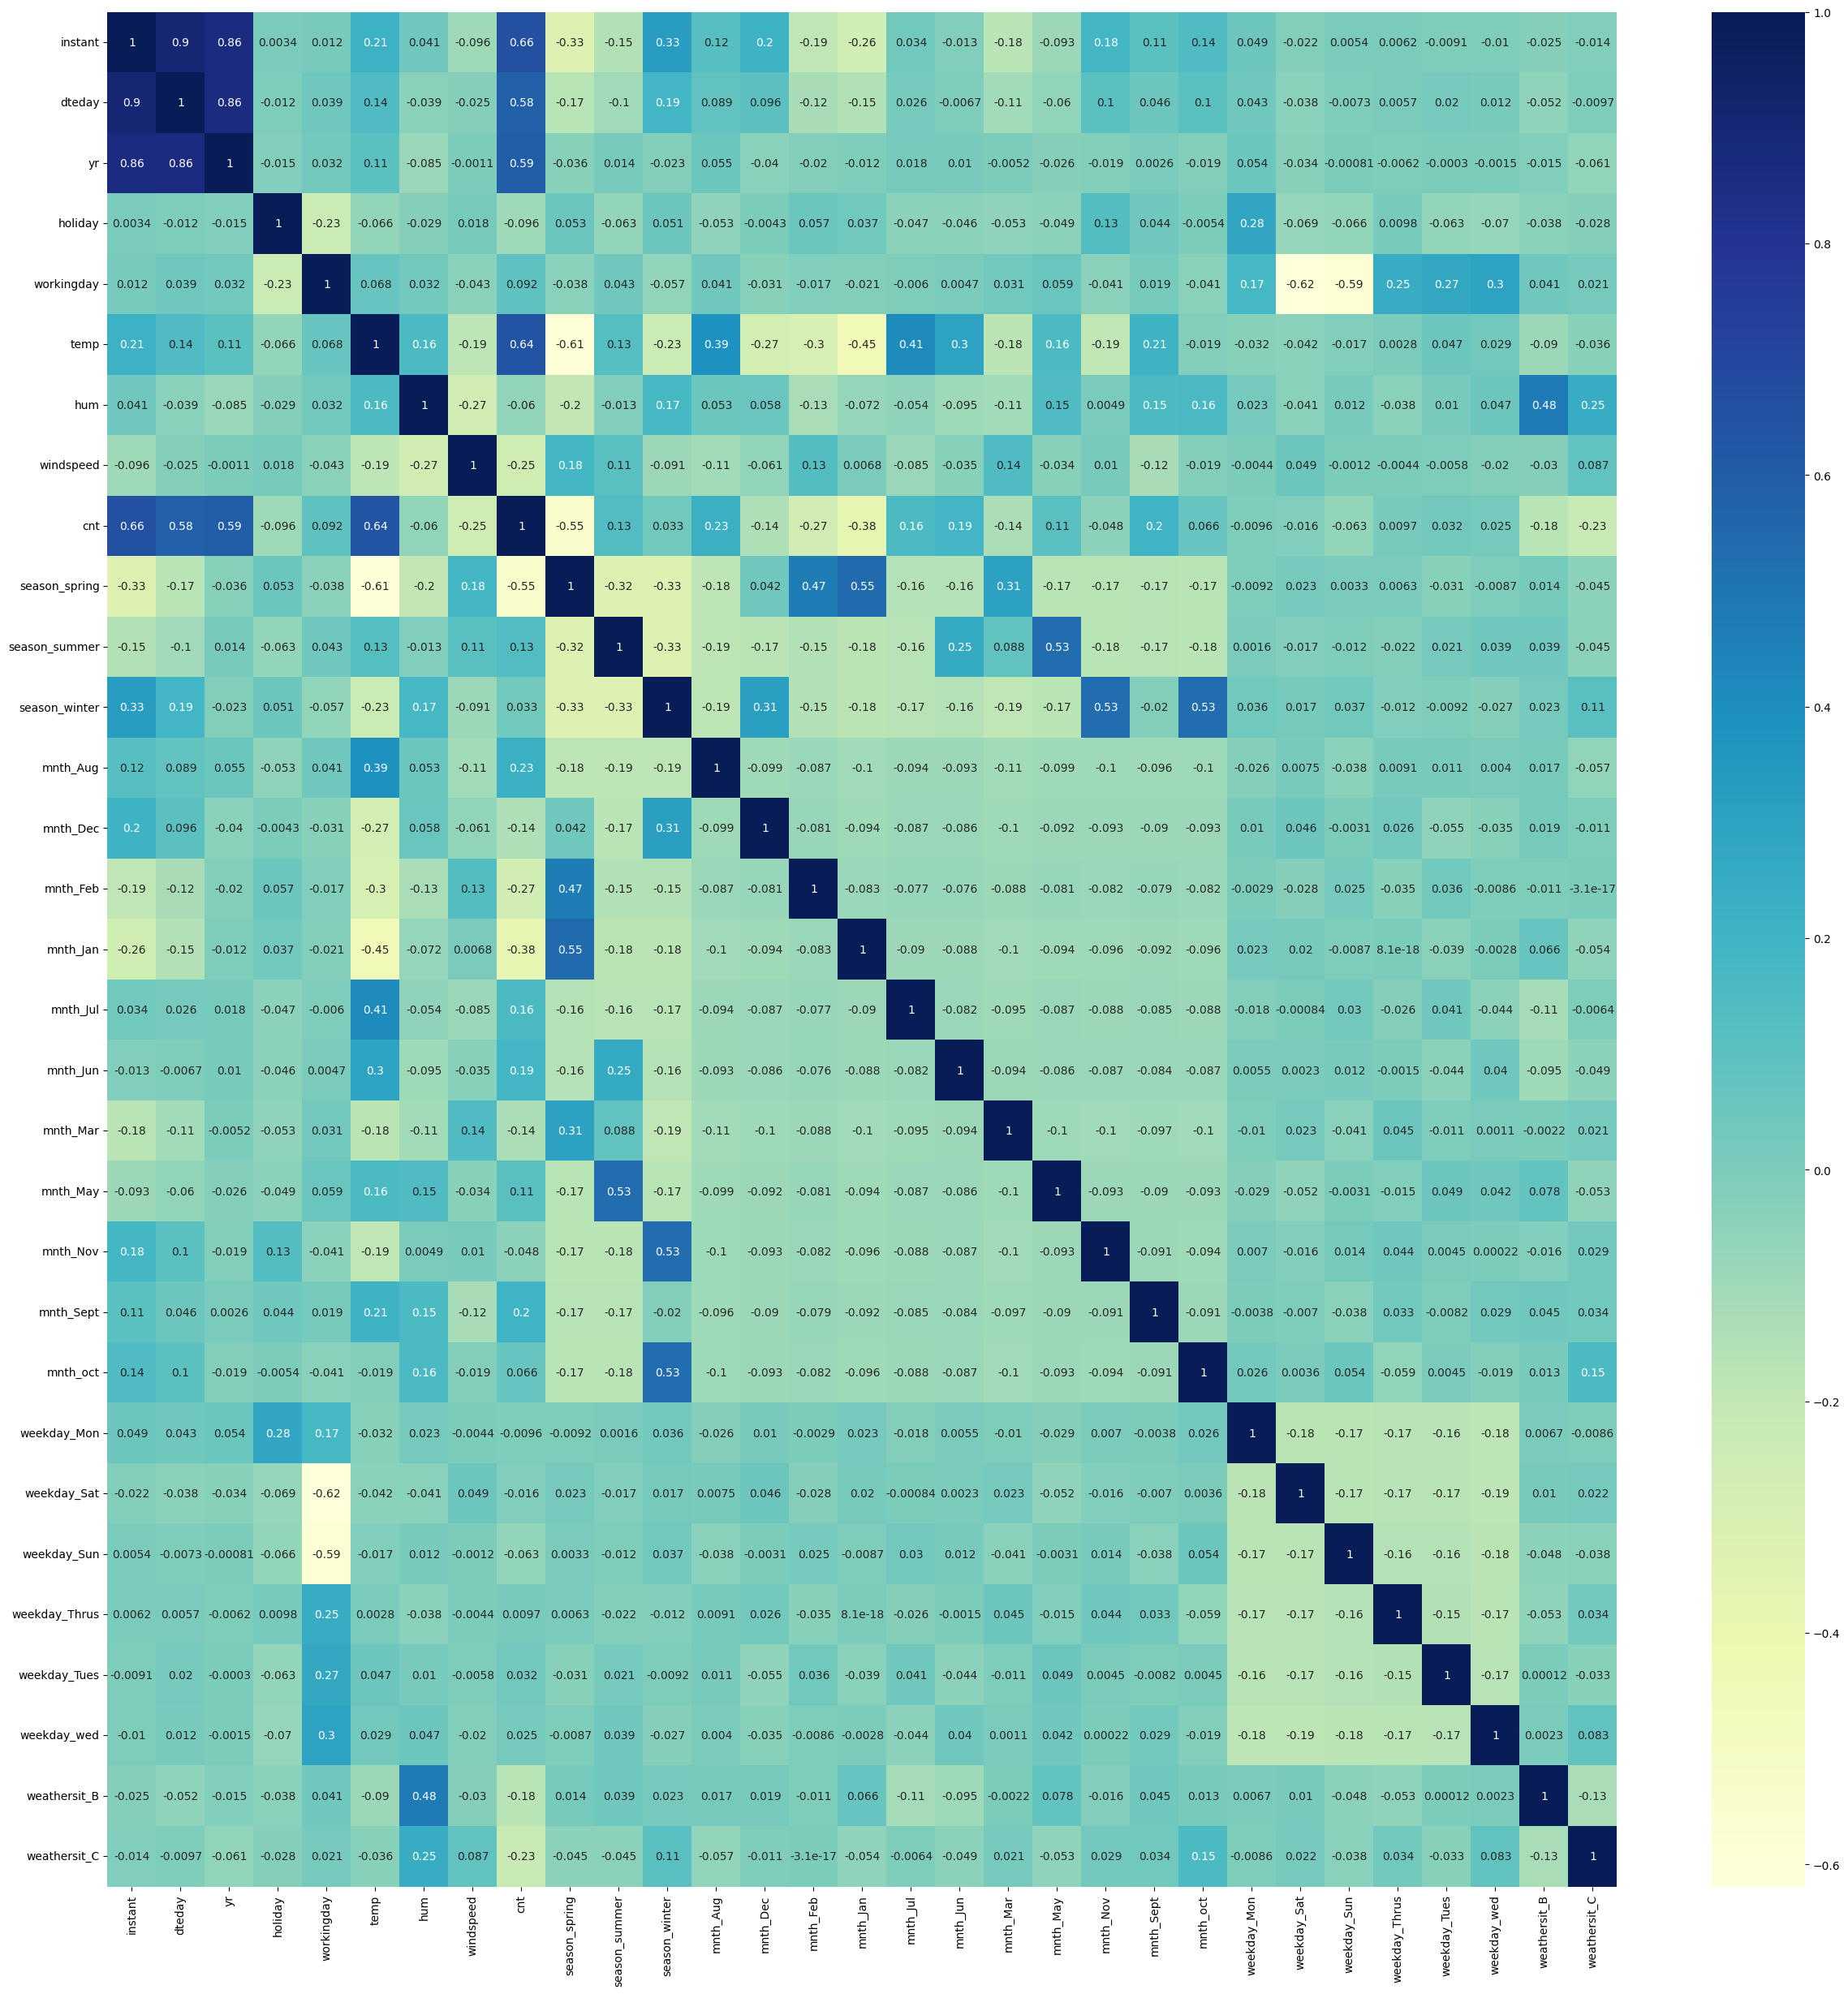

In [ ]:
# Checking the corelation coefficients to see which variables are highly correlated
plt.figure(figsize=(30,30))
sns.heatmap(df_train.corr(), annot = True, cmap='YlGnBu')
plt.show()